# Plot Notebook

This notebook is intended for reviewers to quickly inspect wheel output plots and numeric metrics for both BASE and 4STEP models.

It uses files under `release/wheel_bundle/case_origin_0635_20220608T180000`.

In [ ]:
# =========================
# 配置与路径准备单元（优先修改这里）
#
# 作用：
# 1) 统一管理推理和绘图使用的所有配置项，避免在多个单元里来回修改。
# 2) 自动定位仓库根目录与 case 数据目录，确保在不同工作目录下也能运行。
# 3) 提前打印关键输入/输出路径是否存在，帮助快速定位环境问题。
#
# 使用建议：
# - 简单复现通常只需要修改 CONFIG 字典。
# - device_mode 支持 auto/cpu/cuda；auto 会自动探测 GPU 可用性。
# =========================

from pathlib import Path
import sys
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / "release" / "wheel_bundle").exists() and (p / "agents").exists():
            return p
    raise FileNotFoundError("Could not locate repository root from current working directory.")


# ===== Config (edit here only) =====
CONFIG = {
    # path config
    "case_dirname": "case_origin_0635_20220608T180000",
    "run_rollout_script_rel": "release/wheel_bundle/run_multistep_rollout.py",
    "python_executable": sys.executable,

    # device config: auto | cpu | cuda
    "device_mode": "auto",

    # inference switches
    "run_base_infer": True,
    "run_4step_infer": True,

    # BASE rollout config (统一为24小时)
    "base_input_name": "scs0875_BASE_reference_io.nc",
    "base_output_name": "scs0875_BASE_rollout_24h.nc",
    "base_hours": 24,

    # 4STEP rollout config (统一为24小时)
    "step4_input_name": "scs0875_4STEP_reference_io.nc",
    "step4_output_name": "scs0875_4STEP_rollout_24h.nc",
    "step4_hours": 24,

    # plotting config: 6/12/24h + 对应GT
    "case_origin_index": 635,
    "plot_lead_hours": (6, 12, 24),
    "plot_channel_index": 15,
    "plot_channel_name": "Q850",
    "plot_apply_z_div_9p8": True,
    "plot_cmap": "jet",

    # output image filenames
    "base_png_name": "pred_vs_gt_wheel_case635_base.png",
    "step4_png_name": "pred_vs_gt_wheel_case635_4step.png",
}

ROOT = find_repo_root(Path.cwd())
WHEEL_BUNDLE_DIR = ROOT / "release" / "wheel_bundle"
CASE_DIR = WHEEL_BUNDLE_DIR / CONFIG["case_dirname"]

RUN_ROLLOUT_SCRIPT = ROOT / CONFIG["run_rollout_script_rel"]

BASE_INPUT_NC = CASE_DIR / CONFIG["base_input_name"]
BASE_OUTPUT_NC = CASE_DIR / CONFIG["base_output_name"]
STEP4_INPUT_NC = CASE_DIR / CONFIG["step4_input_name"]
STEP4_OUTPUT_NC = CASE_DIR / CONFIG["step4_output_name"]

BASE_PNG = CASE_DIR / CONFIG["base_png_name"]
STEP4_PNG = CASE_DIR / CONFIG["step4_png_name"]

print("ROOT:", ROOT)
print("CASE_DIR:", CASE_DIR)
print("RUN_ROLLOUT_SCRIPT:", RUN_ROLLOUT_SCRIPT)
for p in [BASE_INPUT_NC, BASE_OUTPUT_NC, STEP4_INPUT_NC, STEP4_OUTPUT_NC, BASE_PNG, STEP4_PNG]:
    print(p.name, "exists=", p.exists())

ROOT: /home/fengj/code/github/raim_scs
CASE_DIR: /home/fengj/code/github/raim_scs/release/wheel_bundle/case_origin_0635_20220608T180000
RUN_ROLLOUT_SCRIPT: /home/fengj/code/github/raim_scs/release/wheel_bundle/run_multistep_rollout.py
scs0875_BASE_reference_io.nc exists= True
scs0875_BASE_rollout_24h.nc exists= True
scs0875_4STEP_reference_io.nc exists= True
scs0875_4STEP_rollout_24h.nc exists= True
pred_vs_gt_wheel_case635_base.png exists= True
pred_vs_gt_wheel_case635_4step.png exists= True


In [ ]:
# =========================
# 推理执行单元（仅生成推理输出）
#
# 作用：
# 1) 根据第一个单元的配置，分别执行 BASE 和 4STEP 的 rollout 推理。
# 2) 支持 CPU/GPU：
#    - device_mode="auto" 时自动探测 CUDA；可用则用 cuda，否则用 cpu。
#    - device_mode="cpu" 或 "cuda" 时强制使用指定设备。
# =========================

import subprocess
import shlex


def resolve_device(mode: str) -> str:
    mode = str(mode).lower().strip()
    if mode in {"cpu", "cuda"}:
        return mode
    if mode != "auto":
        raise ValueError(f"Unsupported device_mode={mode}, expected auto/cpu/cuda")

    try:
        import torch  # optional dependency in reviewer env
        return "cuda" if torch.cuda.is_available() else "cpu"
    except Exception:
        return "cpu"


def run_cmd(cmd, cwd: Path):
    print("\n$", shlex.join([str(x) for x in cmd]))
    proc = subprocess.run(
        [str(x) for x in cmd],
        cwd=str(cwd),
        text=True,
        capture_output=True,
        check=False,
    )
    if proc.stdout:
        print(proc.stdout)
    if proc.returncode != 0:
        if proc.stderr:
            print(proc.stderr)
        raise RuntimeError(f"Command failed with return code {proc.returncode}")


device = resolve_device(CONFIG["device_mode"])
print(f"Selected device: {device}")

if CONFIG["run_base_infer"]:
    run_cmd(
        [
            CONFIG["python_executable"],
            str(RUN_ROLLOUT_SCRIPT),
            "--model", "base",
            "--input", str(BASE_INPUT_NC),
            "--output", str(BASE_OUTPUT_NC),
            "--hours", str(CONFIG["base_hours"]),
            "--device", device,
        ],
        cwd=ROOT,
    )

if CONFIG["run_4step_infer"]:
    run_cmd(
        [
            CONFIG["python_executable"],
            str(RUN_ROLLOUT_SCRIPT),
            "--model", "4step",
            "--input", str(STEP4_INPUT_NC),
            "--output", str(STEP4_OUTPUT_NC),
            "--hours", str(CONFIG["step4_hours"]),
            "--device", device,
        ],
        cwd=ROOT,
    )

print("\nGenerated/updated inference files:")
for p in [BASE_OUTPUT_NC, STEP4_OUTPUT_NC]:
    print(p, "exists=", p.exists())

Selected device: cuda

$ /home/fengj/usr/anaconda3/envs/aifs/bin/python /home/fengj/code/github/raim_scs/release/wheel_bundle/run_multistep_rollout.py --model base --input /home/fengj/code/github/raim_scs/release/wheel_bundle/case_origin_0635_20220608T180000/scs0875_BASE_reference_io.nc --output /home/fengj/code/github/raim_scs/release/wheel_bundle/case_origin_0635_20220608T180000/scs0875_BASE_rollout_24h.nc --hours 24 --device cuda

$ /home/fengj/usr/anaconda3/envs/aifs/bin/python /home/fengj/code/github/raim_scs/release/wheel_bundle/run_multistep_rollout.py --model 4step --input /home/fengj/code/github/raim_scs/release/wheel_bundle/case_origin_0635_20220608T180000/scs0875_4STEP_reference_io.nc --output /home/fengj/code/github/raim_scs/release/wheel_bundle/case_origin_0635_20220608T180000/scs0875_4STEP_rollout_24h.nc --hours 24 --device cuda

Generated/updated inference files:
/home/fengj/code/github/raim_scs/release/wheel_bundle/case_origin_0635_20220608T180000/scs0875_BASE_rollout_2

Saved BASE figure: /home/fengj/code/github/raim_scs/release/wheel_bundle/case_origin_0635_20220608T180000/pred_vs_gt_wheel_case635_base.png


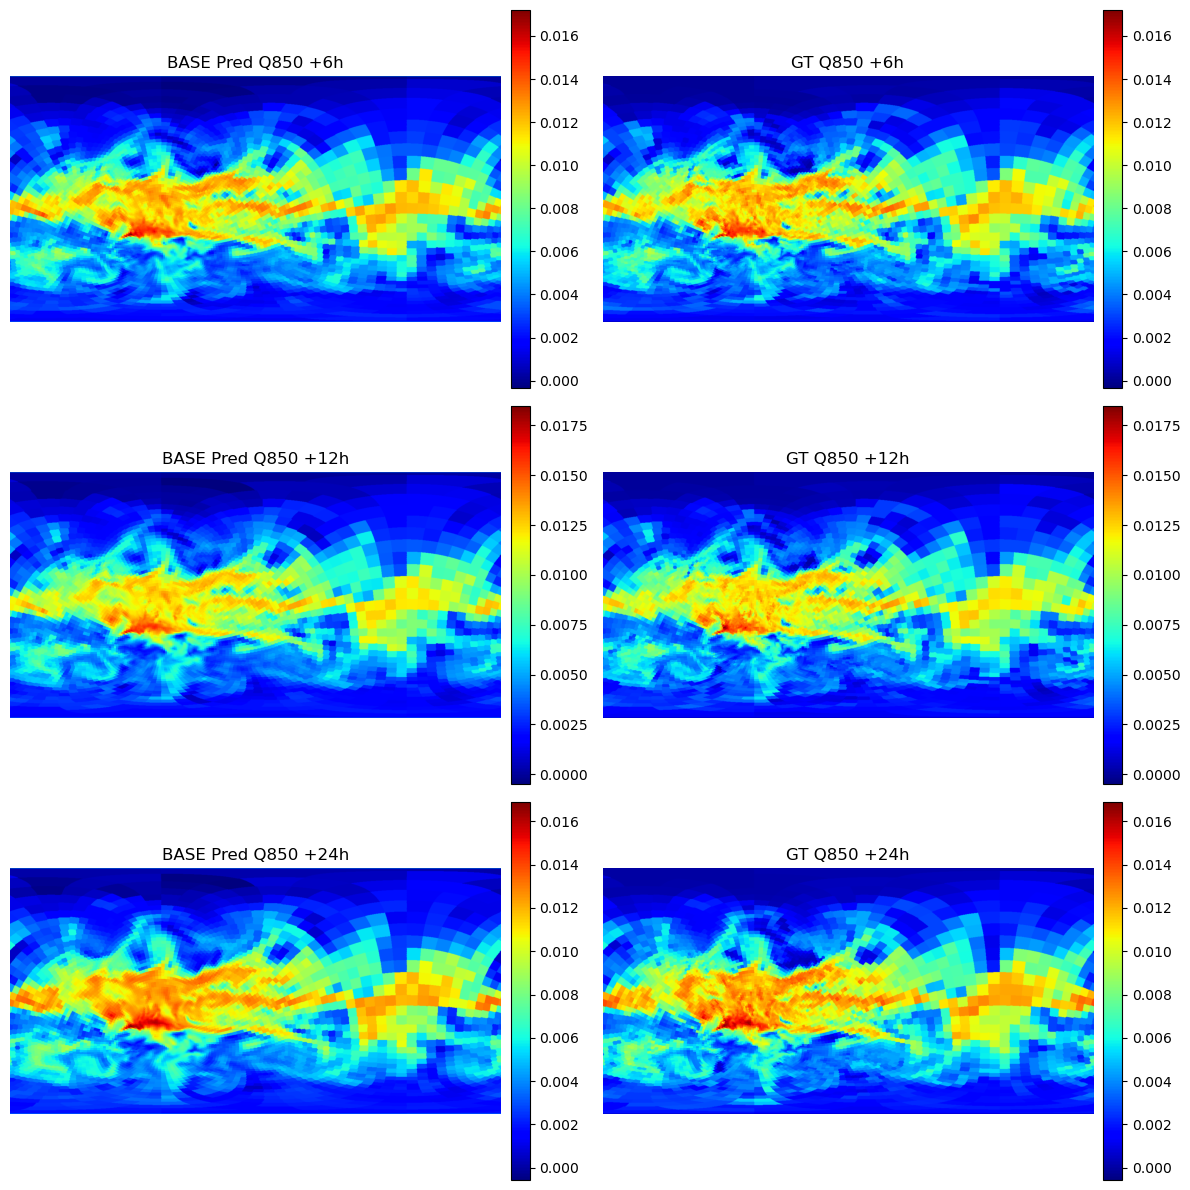

In [9]:
# =========================
# BASE 结果重绘单元（从头绘制，不读取已有PNG）
#
# 作用：
# 1) 从 BASE 推理输出 nc 中读取预报场（wheel 输出）。
# 2) 从 agents/scs0875_BASE/test 中读取 case=635 的 GT 子集样本。
# 3) 将 GT 从标准化的 SCS 网格反标准化并重建到经纬网格。
# 4) 绘制 lead=6/12/24h 的 Pred vs GT（每行一个时次，左Pred右GT）。
# 5) 保存图片到 CONFIG 里指定的 BASE_PNG 路径。
# =========================

import numpy as np
import xarray as xr

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from notebooks.outdata import load_mean_std_vector, denorm_scs
from notebooks.vis import reconstruct_lonlat

lead_hours = [int(h) for h in CONFIG["plot_lead_hours"]]
lead_indices = [h // 6 - 1 for h in lead_hours]
ch_idx = int(CONFIG["plot_channel_index"])
ch_name = str(CONFIG["plot_channel_name"])
apply_z_scale = bool(CONFIG["plot_apply_z_div_9p8"])

# 1) 读取 wheel 推理输出
if not BASE_OUTPUT_NC.exists():
    raise FileNotFoundError(f"Missing BASE output nc: {BASE_OUTPUT_NC}")

ds_base = xr.open_dataset(BASE_OUTPUT_NC)
pred_base = np.asarray(ds_base["pred_phys"].values, dtype=np.float32)  # [B,T,C,H,W]
if pred_base.ndim != 5:
    raise ValueError(f"Unexpected pred_phys shape for BASE: {pred_base.shape}")
pred_base = pred_base[0]

# 2) 读取 GT 子集（标准化 SCS 网格）
base_test_dir = ROOT / "agents" / "scs0875_BASE" / "test"
indices = np.load(base_test_dir / "subset_origin_indices_ar_15days.npy")
gts_subset = np.load(base_test_dir / "gts_subset_ar_15days.npy")

matches = np.where(indices == int(CONFIG["case_origin_index"]))[0]
if matches.size == 0:
    raise ValueError(f"case_origin_index={CONFIG['case_origin_index']} not found in BASE subset indices")
local_idx = int(matches[0])
gt_base_scs_norm = np.asarray(gts_subset[local_idx], dtype=np.float32)  # [T,C,F,H,W]

# 3) 反标准化 + 经纬网格重建
mean_std_path = ROOT / "notebooks" / "predata" / "mean_std_data.npz"
mapping_path = ROOT / "notebooks" / "predata" / "scs_mapping_ch0.875.npz"
mean_vec, std_vec = load_mean_std_vector(mean_std_path)

gt_base_scs = denorm_scs(gt_base_scs_norm, mean_vec, std_vec).astype(np.float32)
gt_base_ll = np.asarray(reconstruct_lonlat(gt_base_scs, mapping_path), dtype=np.float32)  # [T,C,721,1440]

# 4) 绘图（每个lead一行：Pred | GT）
max_t = pred_base.shape[0]
for t in lead_indices:
    if t < 0 or t >= max_t:
        raise IndexError(f"BASE lead index {t} out of range, pred T={max_t}")

nrows = len(lead_indices)
fig, axes = plt.subplots(nrows, 2, figsize=(12, 4 * nrows), squeeze=False)
for r, (lead_h, t) in enumerate(zip(lead_hours, lead_indices)):
    pred2d = np.asarray(pred_base[t, ch_idx], dtype=np.float32).copy()
    gt2d = np.asarray(gt_base_ll[t, ch_idx], dtype=np.float32).copy()

    if apply_z_scale and ch_name.upper().startswith("Z"):
        pred2d = pred2d / 9.8
        gt2d = gt2d / 9.8

    vmin = float(np.nanmin([pred2d.min(), gt2d.min()]))
    vmax = float(np.nanmax([pred2d.max(), gt2d.max()]))
    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-6

    im0 = axes[r, 0].imshow(pred2d, cmap=CONFIG["plot_cmap"], vmin=vmin, vmax=vmax)
    axes[r, 0].set_title(f"BASE Pred {ch_name} +{lead_h}h")
    axes[r, 0].axis("off")
    fig.colorbar(im0, ax=axes[r, 0], fraction=0.045, pad=0.02)

    im1 = axes[r, 1].imshow(gt2d, cmap=CONFIG["plot_cmap"], vmin=vmin, vmax=vmax)
    axes[r, 1].set_title(f"GT {ch_name} +{lead_h}h")
    axes[r, 1].axis("off")
    fig.colorbar(im1, ax=axes[r, 1], fraction=0.045, pad=0.02)

fig.tight_layout()
fig.savefig(BASE_PNG, dpi=150)
print(f"Saved BASE figure: {BASE_PNG}")
plt.show()

Saved 4STEP figure: /home/fengj/code/github/raim_scs/release/wheel_bundle/case_origin_0635_20220608T180000/pred_vs_gt_wheel_case635_4step.png


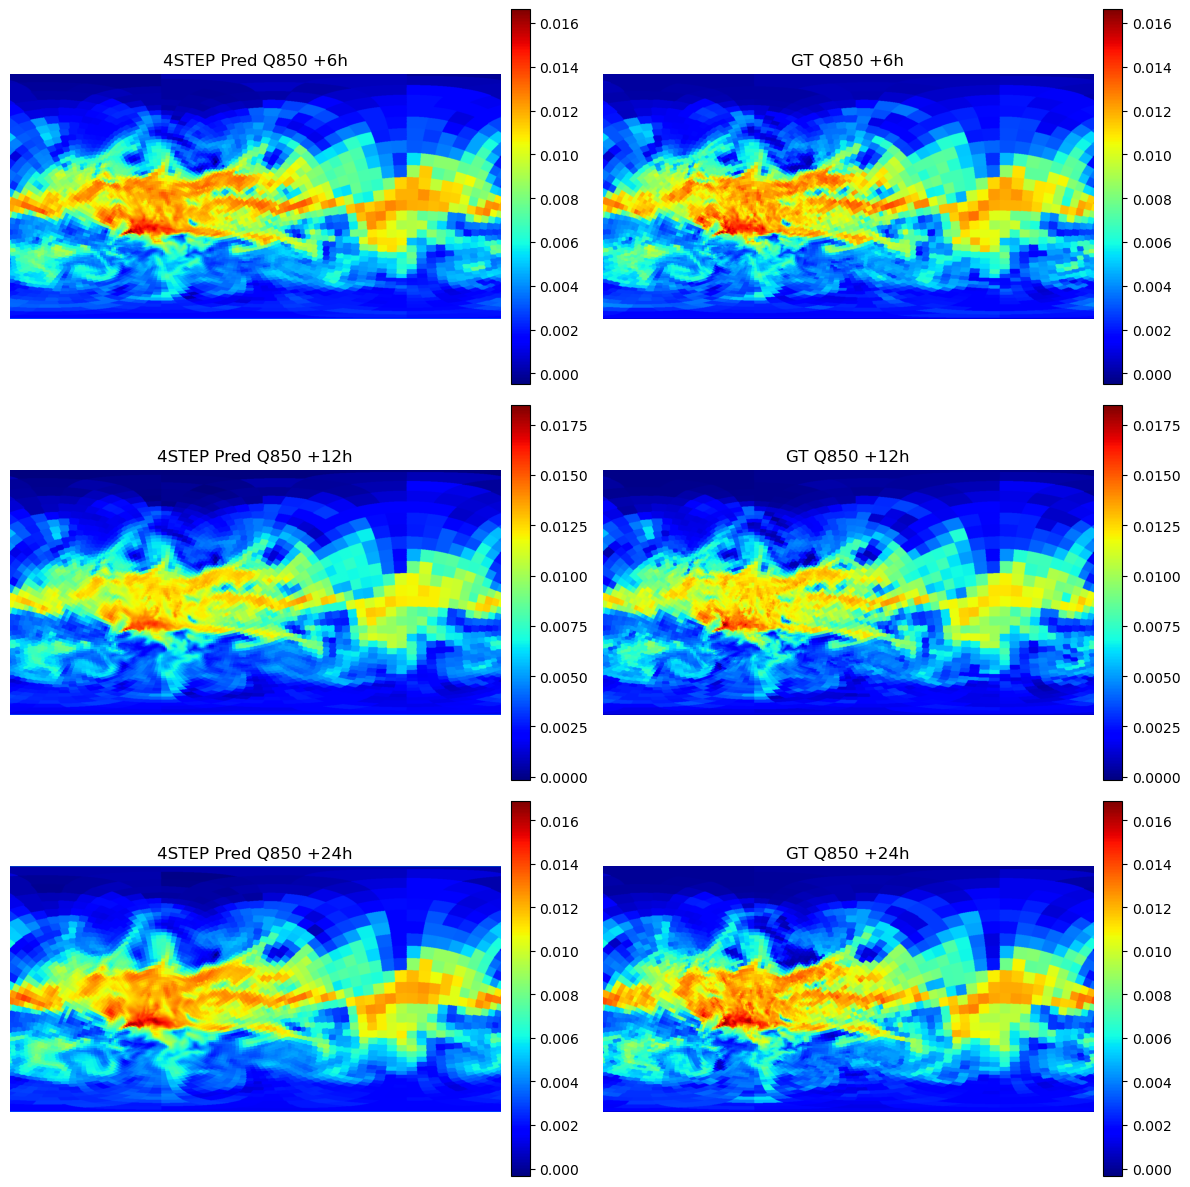

In [10]:
# =========================
# 4STEP 结果重绘单元（从头绘制，不读取已有PNG）
#
# 作用：
# 1) 从 4STEP 推理输出 nc 中读取预报场（wheel 输出）。
# 2) 从 agents/scs0875_4STEP/test 中读取 case=635 的 GT 子集样本。
# 3) 将 GT 从标准化的 SCS 网格反标准化并重建到经纬网格。
# 4) 绘制 lead=6/12/24h 的 Pred vs GT（每行一个时次，左Pred右GT）。
# 5) 保存图片到 CONFIG 里指定的 STEP4_PNG 路径。
# =========================

import numpy as np
import xarray as xr

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from notebooks.outdata import load_mean_std_vector, denorm_scs
from notebooks.vis import reconstruct_lonlat

lead_hours = [int(h) for h in CONFIG["plot_lead_hours"]]
lead_indices = [h // 6 - 1 for h in lead_hours]
ch_idx = int(CONFIG["plot_channel_index"])
ch_name = str(CONFIG["plot_channel_name"])
apply_z_scale = bool(CONFIG["plot_apply_z_div_9p8"])

# 1) 读取 wheel 推理输出
if not STEP4_OUTPUT_NC.exists():
    raise FileNotFoundError(f"Missing 4STEP output nc: {STEP4_OUTPUT_NC}")

ds_step4 = xr.open_dataset(STEP4_OUTPUT_NC)
pred_step4 = np.asarray(ds_step4["pred_phys"].values, dtype=np.float32)  # [B,T,C,H,W]
if pred_step4.ndim != 5:
    raise ValueError(f"Unexpected pred_phys shape for 4STEP: {pred_step4.shape}")
pred_step4 = pred_step4[0]

# 2) 读取 GT 子集（标准化 SCS 网格）
step4_test_dir = ROOT / "agents" / "scs0875_4STEP" / "test"
indices = np.load(step4_test_dir / "subset_origin_indices_ar_15days.npy")
gts_subset = np.load(step4_test_dir / "gts_subset_ar_15days.npy")

matches = np.where(indices == int(CONFIG["case_origin_index"]))[0]
if matches.size == 0:
    raise ValueError(f"case_origin_index={CONFIG['case_origin_index']} not found in 4STEP subset indices")
local_idx = int(matches[0])
gt_step4_scs_norm = np.asarray(gts_subset[local_idx], dtype=np.float32)  # [T,C,F,H,W]

# 3) 反标准化 + 经纬网格重建
mean_std_path = ROOT / "notebooks" / "predata" / "mean_std_data.npz"
mapping_path = ROOT / "notebooks" / "predata" / "scs_mapping_ch0.875.npz"
mean_vec, std_vec = load_mean_std_vector(mean_std_path)

gt_step4_scs = denorm_scs(gt_step4_scs_norm, mean_vec, std_vec).astype(np.float32)
gt_step4_ll = np.asarray(reconstruct_lonlat(gt_step4_scs, mapping_path), dtype=np.float32)  # [T,C,721,1440]

# 4) 绘图（每个lead一行：Pred | GT）
max_t = pred_step4.shape[0]
for t in lead_indices:
    if t < 0 or t >= max_t:
        raise IndexError(f"4STEP lead index {t} out of range, pred T={max_t}")

nrows = len(lead_indices)
fig, axes = plt.subplots(nrows, 2, figsize=(12, 4 * nrows), squeeze=False)
for r, (lead_h, t) in enumerate(zip(lead_hours, lead_indices)):
    pred2d = np.asarray(pred_step4[t, ch_idx], dtype=np.float32).copy()
    gt2d = np.asarray(gt_step4_ll[t, ch_idx], dtype=np.float32).copy()

    if apply_z_scale and ch_name.upper().startswith("Z"):
        pred2d = pred2d / 9.8
        gt2d = gt2d / 9.8

    vmin = float(np.nanmin([pred2d.min(), gt2d.min()]))
    vmax = float(np.nanmax([pred2d.max(), gt2d.max()]))
    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-6

    im0 = axes[r, 0].imshow(pred2d, cmap=CONFIG["plot_cmap"], vmin=vmin, vmax=vmax)
    axes[r, 0].set_title(f"4STEP Pred {ch_name} +{lead_h}h")
    axes[r, 0].axis("off")
    fig.colorbar(im0, ax=axes[r, 0], fraction=0.045, pad=0.02)

    im1 = axes[r, 1].imshow(gt2d, cmap=CONFIG["plot_cmap"], vmin=vmin, vmax=vmax)
    axes[r, 1].set_title(f"GT {ch_name} +{lead_h}h")
    axes[r, 1].axis("off")
    fig.colorbar(im1, ax=axes[r, 1], fraction=0.045, pad=0.02)

fig.tight_layout()
fig.savefig(STEP4_PNG, dpi=150)
print(f"Saved 4STEP figure: {STEP4_PNG}")
plt.show()